<a href="https://colab.research.google.com/github/NK47GG/churn-prediction/blob/main/UAS_Churn_Prediction_A11_2023_14862_Stefanus_Loveniko_Putra_Sinory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science — Customer Churn Prediction (REVISI)
## Sales & Marketing Customer Dataset

**Versi ini memperbaiki 2 isu *data leakage* dan beberapa isu metodologi pada notebook sebelumnya.**

### Ringkasan Perbaikan

| # | Masalah pada notebook lama | Perbaikan pada notebook ini |
|---|---|---|
| 1 | Imputasi missing value, IQR outlier-capping, dan Label Encoding **dihitung dari seluruh dataset (train+test) SEBELUM split** → statistik dari data uji ikut "bocor" ke proses pembersihan data latih | Train-test split dilakukan **lebih awal** (segera setelah feature engineering tanggal yang deterministik). Median, mode, batas IQR, dan encoder semuanya **di-fit hanya pada data latih**, lalu diterapkan ke data uji |
| 2 | `SMOTE` diterapkan **sekali ke seluruh data latih**, lalu data hasil SMOTE itu dimasukkan ke `RandomizedSearchCV(cv=5)` → sampel sintetis bisa "menyebar" antara fold latih dan fold validasi di dalam proses CV, sehingga skor CV jadi bias optimis (lihat gap besar antara *Best F1 (CV)* ≈ 0.78–0.92 vs F1 data uji asli ≈ 0.46–0.62 pada notebook lama) | `SMOTE` dimasukkan ke dalam `imblearn.pipeline.Pipeline` bersama classifier, lalu **pipeline itulah** yang dimasukkan ke `RandomizedSearchCV`. Dengan begitu, SMOTE hanya dijalankan pada fold latih di setiap iterasi CV, fold validasi tetap asli (imbalanced) → skor CV jujur |
| 3 | Skenario **Direct Modeling** men-*drop* hampir semua kolom kategorikal & tanggal, padahal soal UAS poin D.2.1 meminta **seluruh kolom lain** dipakai sebagai fitur | Semua 29 kolom fitur dipertahankan. Encoding/imputasi minimal tetap diberikan (karena model sklearn tidak bisa membaca teks mentah), tapi statistiknya tetap di-fit hanya dari data latih |
| 4 | Fitur kategorikal nominal (`gender`, `country`, `city`, dst.) di-*Label Encode* jadi angka 0..N → Logistic Regression & KNN (di dalam Voting Classifier) salah mengasumsikan ada hubungan ordinal/jarak antar kategori yang sebenarnya tidak ada. Kolom hasil label-encoding ini juga **tidak ikut di-scale**, padahal KNN sangat sensitif terhadap skala | Fitur nominal di-**One-Hot Encode** (dengan `min_frequency` untuk kategori jarang) dan semua fitur numerik kontinu di-**scale**, dibungkus dalam satu `ColumnTransformer` |
| 5 | Pada skenario Tuning, Logistic Regression & Random Forest dilatih ulang dengan data yang sudah di-SMOTE, tapi Voting Classifier final dilatih **tanpa SMOTE** → perbandingan 3 model di skenario yang sama jadi tidak apple-to-apple (Voting Classifier selalu rugi di recall) | Ketiga model final (LR, RF, Voting) sama-sama dibungkus `ImbPipeline(SMOTE, classifier)` sehingga treatment-nya konsisten |

> **Catatan tambahan:** fitur hasil rekayasa `days_since_purchase` dan `tenure_days` (turunan dari `last_purchase_date`) cukup wajar dipakai untuk prediksi churn, tapi **perlu dicek ke sumber data Kaggle**-nya apakah kolom `churn` di dataset itu memang didefinisikan berdasarkan lamanya tidak bertransaksi. Jika iya, fitur ini berisiko jadi *proxy* langsung dari label (leakage semantik, bukan leakage teknis). Pada feature importance, kontribusinya sedang (~3%), jadi kemungkinan aman, tapi tetap perlu diwaspadai.


In [ ]:
!pip install -q --upgrade scikit-learn==1.9.0 imbalanced-learn==0.14.2

## 0. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import os

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
print('Library berhasil diimport (ditambahkan: ColumnTransformer, OneHotEncoder, OrdinalEncoder, SimpleImputer, ImbPipeline).')


Library berhasil diimport (ditambahkan: ColumnTransformer, OneHotEncoder, OrdinalEncoder, SimpleImputer, ImbPipeline).


---
## 1. Exploratory Data Analysis (EDA)


### 1.1 Load Dataset dan Tampilan Awal

In [ ]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f'Ukuran dataset : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print('\n5 Baris Pertama:')
display(df.head())

Ukuran dataset : 15,000 baris x 30 kolom

5 Baris Pertama:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.2 Informasi Dataset

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

### 1.3 Statistik Deskriptif

In [ ]:
display(df.describe().T.style.background_gradient(cmap='Blues'))


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.000000,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.000000,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.000000,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.000000,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.000000,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.000000,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.000000,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.000000,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.000000,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.000000,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


### 1.4 Persentase Missing Value

Kolom dengan Missing Value:


,Kolom,Missing (%)
0,coupon_code,40.886667
1,age,8.000000
2,total_spent,7.000000
3,gender,4.920000
4,satisfaction_score,4.680000


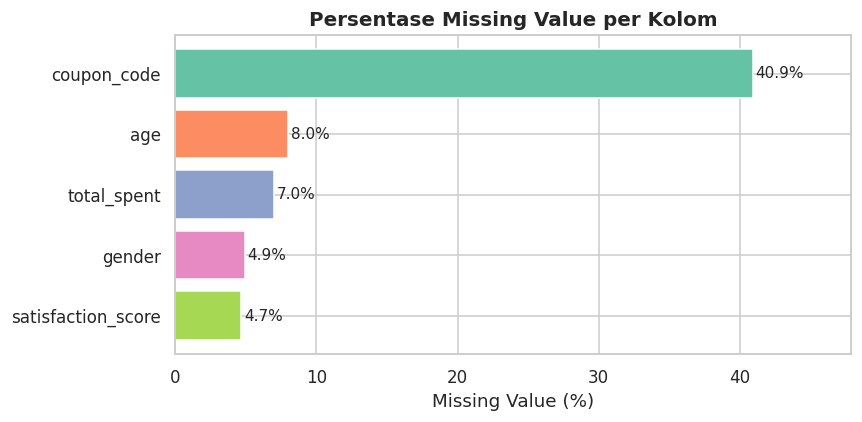

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Kolom', 'Missing (%)']
print('Kolom dengan Missing Value:')
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df['Kolom'], missing_df['Missing (%)'],
               color=sns.color_palette('Set2', len(missing_df)))
ax.set_xlabel('Missing Value (%)')
ax.set_title('Persentase Missing Value per Kolom', fontweight='bold')
ax.invert_yaxis()
for bar, pct in zip(bars, missing_df['Missing (%)']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, missing_df['Missing (%)'].max() + 7)
plt.tight_layout()
plt.show()

### 1.5 Distribusi Variabel Target (Churn)

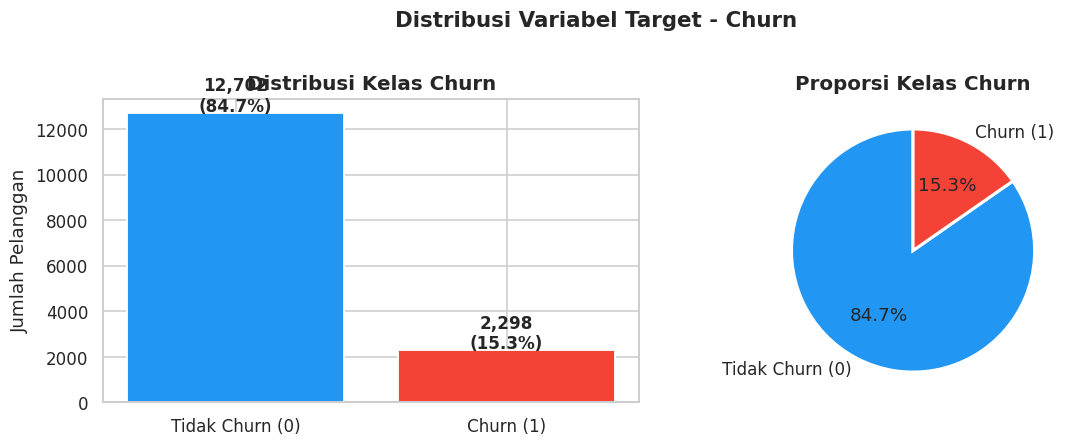

Tidak Churn : 12,702 (84.7%)
Churn       : 2,298 (15.3%)
Dataset tidak seimbang (imbalanced) - perlu diperhatikan dalam pemodelan.


In [ ]:
churn_count = df['churn'].value_counts()
churn_pct   = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2196F3', '#F44336']

axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_count.values,
            color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Kelas Churn', fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, (v, p) in enumerate(zip(churn_count.values, churn_pct.values)):
    axes[0].text(i, v + 60, f'{v:,}\n({p:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

axes[1].pie(churn_count.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontweight='bold')

plt.suptitle('Distribusi Variabel Target - Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Tidak Churn : {churn_count[0]:,} ({churn_pct[0]:.1f}%)')
print(f'Churn       : {churn_count[1]:,} ({churn_pct[1]:.1f}%)')
print('Dataset tidak seimbang (imbalanced) - perlu diperhatikan dalam pemodelan.')

### 1.6 Heatmap Korelasi Fitur Numerik

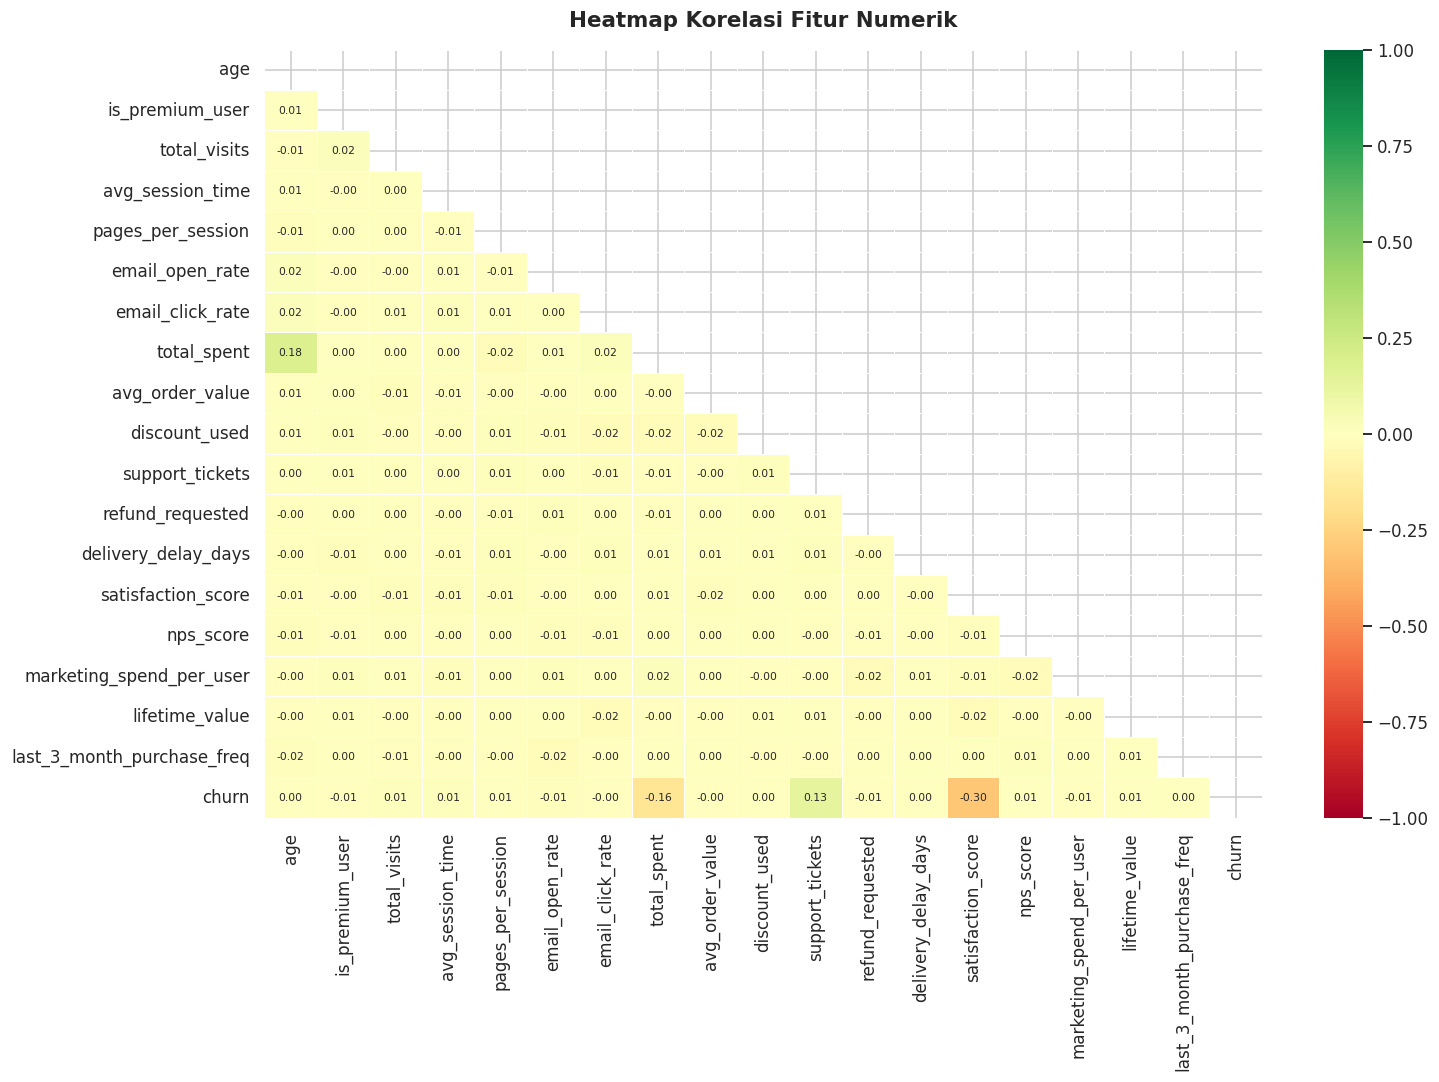

Korelasi Fitur terhadap Churn (top 10):
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Korelasi Fitur terhadap Churn (top 10):')
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print(churn_corr.head(10).to_string())

### 1.7 Distribusi Fitur Kategorik terhadap Churn

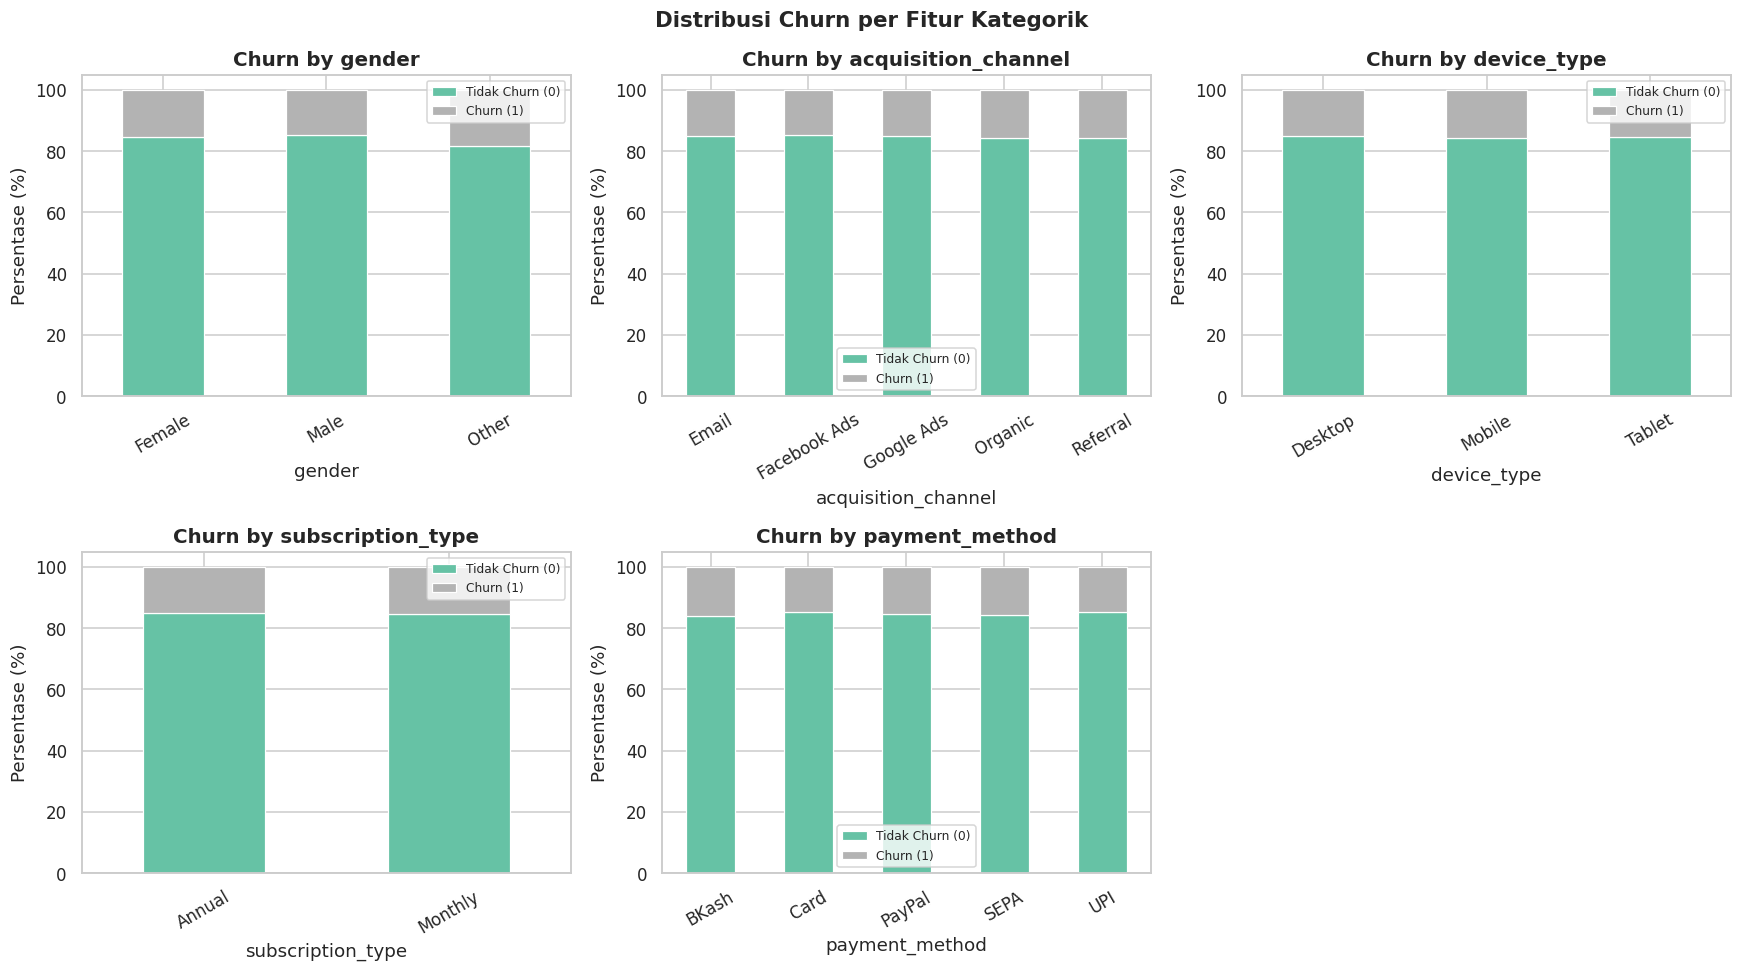

In [ ]:
cat_cols_eda = ['gender', 'acquisition_channel', 'device_type',
                'subscription_type', 'payment_method']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    ct = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2',
                edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Churn by {col}', fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['Tidak Churn (0)', 'Churn (1)'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Churn per Fitur Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Persiapan Data Bersama — Feature Engineering Deterministik (SEBELUM Split)

Hanya transformasi **per-baris** yang dilakukan di sini (drop kolom ID, konversi tanggal, flag biner).
Tidak ada median/mean/mode/kelas-kategori/IQR yang dihitung di sini, sehingga tahap ini **aman**
dilakukan sebelum train-test split — tidak ada informasi data uji yang bisa "bocor" ke data latih.


In [ ]:
df_eng = df.copy()

dup = df_eng.duplicated().sum()
df_eng.drop_duplicates(inplace=True)
print(f'Duplikat ditemukan dan dihapus : {dup}')
print(f'Shape setelah drop duplikat    : {df_eng.shape}')

df_eng.drop(columns=['customer_id'], inplace=True)

df_eng['signup_date']        = pd.to_datetime(df_eng['signup_date'])
df_eng['last_purchase_date'] = pd.to_datetime(df_eng['last_purchase_date'])

# REF_DATE adalah KONSTANTA tetap (bukan statistik dataset) -> aman dipakai sebelum split
REF_DATE = pd.Timestamp('2025-01-01')
df_eng['days_since_signup']   = (REF_DATE - df_eng['signup_date']).dt.days
df_eng['days_since_purchase'] = (REF_DATE - df_eng['last_purchase_date']).dt.days
df_eng['signup_month']        = df_eng['signup_date'].dt.month
df_eng['tenure_days']         = (df_eng['last_purchase_date'] - df_eng['signup_date']).dt.days
df_eng.drop(columns=['signup_date', 'last_purchase_date'], inplace=True)

# coupon_code: banyak missing -> ubah jadi flag biner (transformasi per baris)
df_eng['has_coupon'] = df_eng['coupon_code'].notna().astype(int)
df_eng.drop(columns=['coupon_code'], inplace=True)

print(f'\nShape setelah feature engineering : {df_eng.shape}')
print('Fitur baru: days_since_signup, days_since_purchase, signup_month, tenure_days, has_coupon')
print('\nBelum ada imputasi / outlier-capping / encoding / scaling -> semuanya dilakukan SESUDAH split.')


Duplikat ditemukan dan dihapus : 0
Shape setelah drop duplikat    : (15000, 30)

Shape setelah feature engineering : (15000, 31)
Fitur baru: days_since_signup, days_since_purchase, signup_month, tenure_days, has_coupon

Belum ada imputasi / outlier-capping / encoding / scaling -> semuanya dilakukan SESUDAH split.


---
## 3. Train–Test Split (Dilakukan SEKALI, Dipakai Ulang untuk Ketiga Skenario)

Split dilakukan **sebelum** semua proses berbasis statistik (imputasi, outlier-capping, encoding, scaling).
Ketiga skenario (Direct, Preprocessing, Tuning) memakai baris train/test yang **sama persis**, sehingga
perbandingan antar skenario benar-benar adil (lebih kuat daripada sekadar "rasio split yang sama").


In [ ]:
X_raw = df_eng.drop(columns=['churn'])
y     = df_eng['churn']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

print(f'Data Latih  : {X_train_raw.shape[0]:,} sampel')
print(f'Data Uji    : {X_test_raw.shape[0]:,} sampel')
print('Rasio split : 80% train / 20% test (stratified terhadap churn)')


Data Latih  : 12,000 sampel
Data Uji    : 3,000 sampel
Rasio split : 80% train / 20% test (stratified terhadap churn)


---
## 4. Skenario 1 — Direct Modeling (Seluruh Kolom Dipakai, Proses Minimal)

**Perbaikan dari versi lama:** seluruh kolom non-target dipertahankan (sesuai poin D.2.1 di soal UAS),
bukan hanya kolom numerik. Karena model sklearn tidak bisa membaca teks/tanggal mentah, encoding &
imputasi paling minimal tetap diberikan — tapi statistiknya (kategori encoder, median) **di-fit hanya
dari data latih**, lalu diterapkan ke data uji, supaya tidak ada leakage meskipun prosesnya minimal.


In [ ]:
X_train_direct = X_train_raw.copy()
X_test_direct  = X_test_raw.copy()

cat_cols_direct = X_train_direct.select_dtypes(include='object').columns.tolist()
num_cols_direct = [c for c in X_train_direct.columns if c not in cat_cols_direct]

# Encoding minimal (ordinal) - fit HANYA pada data latih
ord_enc_direct = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_direct[cat_cols_direct] = ord_enc_direct.fit_transform(X_train_direct[cat_cols_direct].astype(str))
X_test_direct[cat_cols_direct]  = ord_enc_direct.transform(X_test_direct[cat_cols_direct].astype(str))

# Imputasi minimal (median) - fit HANYA pada data latih
imputer_direct = SimpleImputer(strategy='median')
X_train_direct[num_cols_direct] = imputer_direct.fit_transform(X_train_direct[num_cols_direct])
X_test_direct[num_cols_direct]  = imputer_direct.transform(X_test_direct[num_cols_direct])

print(f'Fitur prediktor (X) : {X_train_direct.shape[1]} kolom (SEMUA kolom non-target)')
print(f'Sampel latih        : {X_train_direct.shape[0]:,}')
print(f'\nFitur yang digunakan:')
print(list(X_train_direct.columns))


Fitur prediktor (X) : 30 kolom (SEMUA kolom non-target)
Sampel latih        : 12,000

Fitur yang digunakan:
['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'days_since_signup', 'days_since_purchase', 'signup_month', 'tenure_days', 'has_coupon']


In [ ]:
# Model 1: Logistic Regression (Konvensional)
lr_direct = LogisticRegression(max_iter=1000, random_state=42)
lr_direct.fit(X_train_direct, y_train)
print('Model 1: Logistic Regression (Konvensional)  - selesai')

# Model 2: Random Forest (Ensemble Bagging)
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train_direct, y_train)
print('Model 2: Random Forest (Ensemble Bagging)    - selesai')

# Model 3: Voting Classifier (Ensemble Voting: LR + RF + KNN)
estimators_d = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
vc_direct = VotingClassifier(estimators=estimators_d, voting='soft')
vc_direct.fit(X_train_direct, y_train)
print('Model 3: Voting Classifier (LR + RF + KNN)   - selesai')


Model 1: Logistic Regression (Konvensional)  - selesai
Model 2: Random Forest (Ensemble Bagging)    - selesai
Model 3: Voting Classifier (LR + RF + KNN)   - selesai


In [ ]:
def evaluate_model(name, model, X_test, y_test, scenario=''):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {name}  [{scenario}]')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Tidak Churn","Churn"])}')

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Tidak Churn', 'Churn']).plot(
                           ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name} [{scenario}]', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Skenario': scenario,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []
print('Fungsi evaluasi siap digunakan.')

Fungsi evaluasi siap digunakan.



  Logistic Regression  [Direct]
  Accuracy  : 0.8467
  Precision : 0.5000
  Recall    : 0.1413
  F1-Score  : 0.2203

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.50      0.14      0.22       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



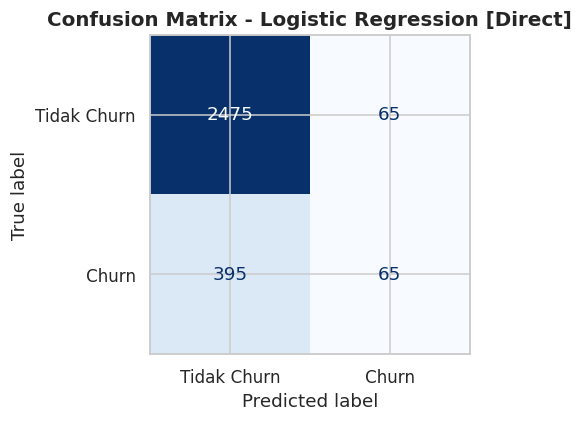


  Random Forest  [Direct]
  Accuracy  : 0.8510
  Precision : 0.5230
  Recall    : 0.3217
  F1-Score  : 0.3984

              precision    recall  f1-score   support

 Tidak Churn       0.89      0.95      0.91      2540
       Churn       0.52      0.32      0.40       460

    accuracy                           0.85      3000
   macro avg       0.70      0.63      0.66      3000
weighted avg       0.83      0.85      0.84      3000



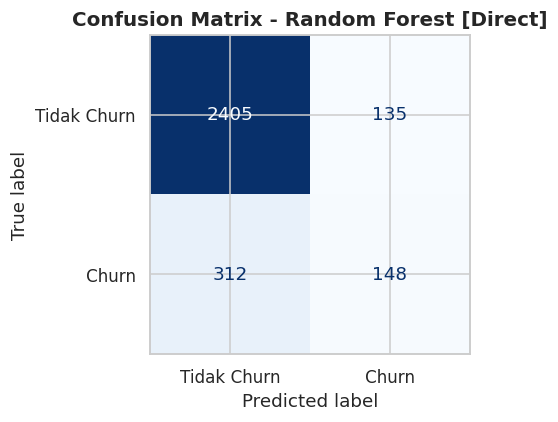


  Voting Classifier  [Direct]
  Accuracy  : 0.8480
  Precision : 0.5233
  Recall    : 0.0978
  F1-Score  : 0.1648

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.98      0.92      2540
       Churn       0.52      0.10      0.16       460

    accuracy                           0.85      3000
   macro avg       0.69      0.54      0.54      3000
weighted avg       0.81      0.85      0.80      3000



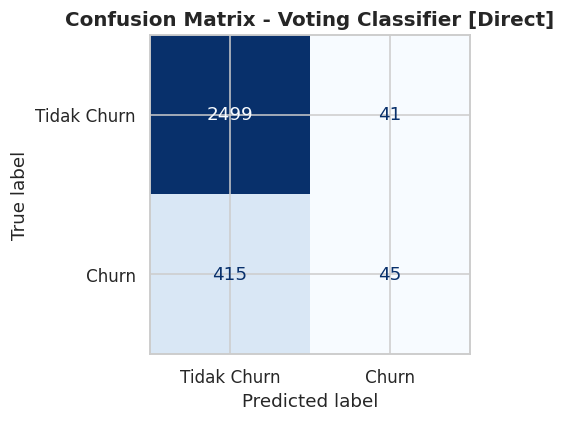

In [ ]:
results.append(evaluate_model('Logistic Regression', lr_direct, X_test_direct, y_test, 'Direct'))
results.append(evaluate_model('Random Forest',       rf_direct, X_test_direct, y_test, 'Direct'))
results.append(evaluate_model('Voting Classifier',   vc_direct, X_test_direct, y_test, 'Direct'))


---
## 5. Skenario 2 — Modeling dengan Preprocessing (Fit Transformer Hanya di Data Latih)

Semua tahap berikut (outlier-capping, imputasi, encoding, scaling) **dihitung hanya dari `X_train_raw`**,
lalu transformasi yang sama (bukan statistik baru) diterapkan ke `X_test_raw`. Ini menutup celah leakage
utama pada notebook lama, sekaligus mengganti Label Encoding nominal dengan **One-Hot Encoding** agar
Logistic Regression & KNN tidak salah mengasumsikan hubungan ordinal antar kategori.


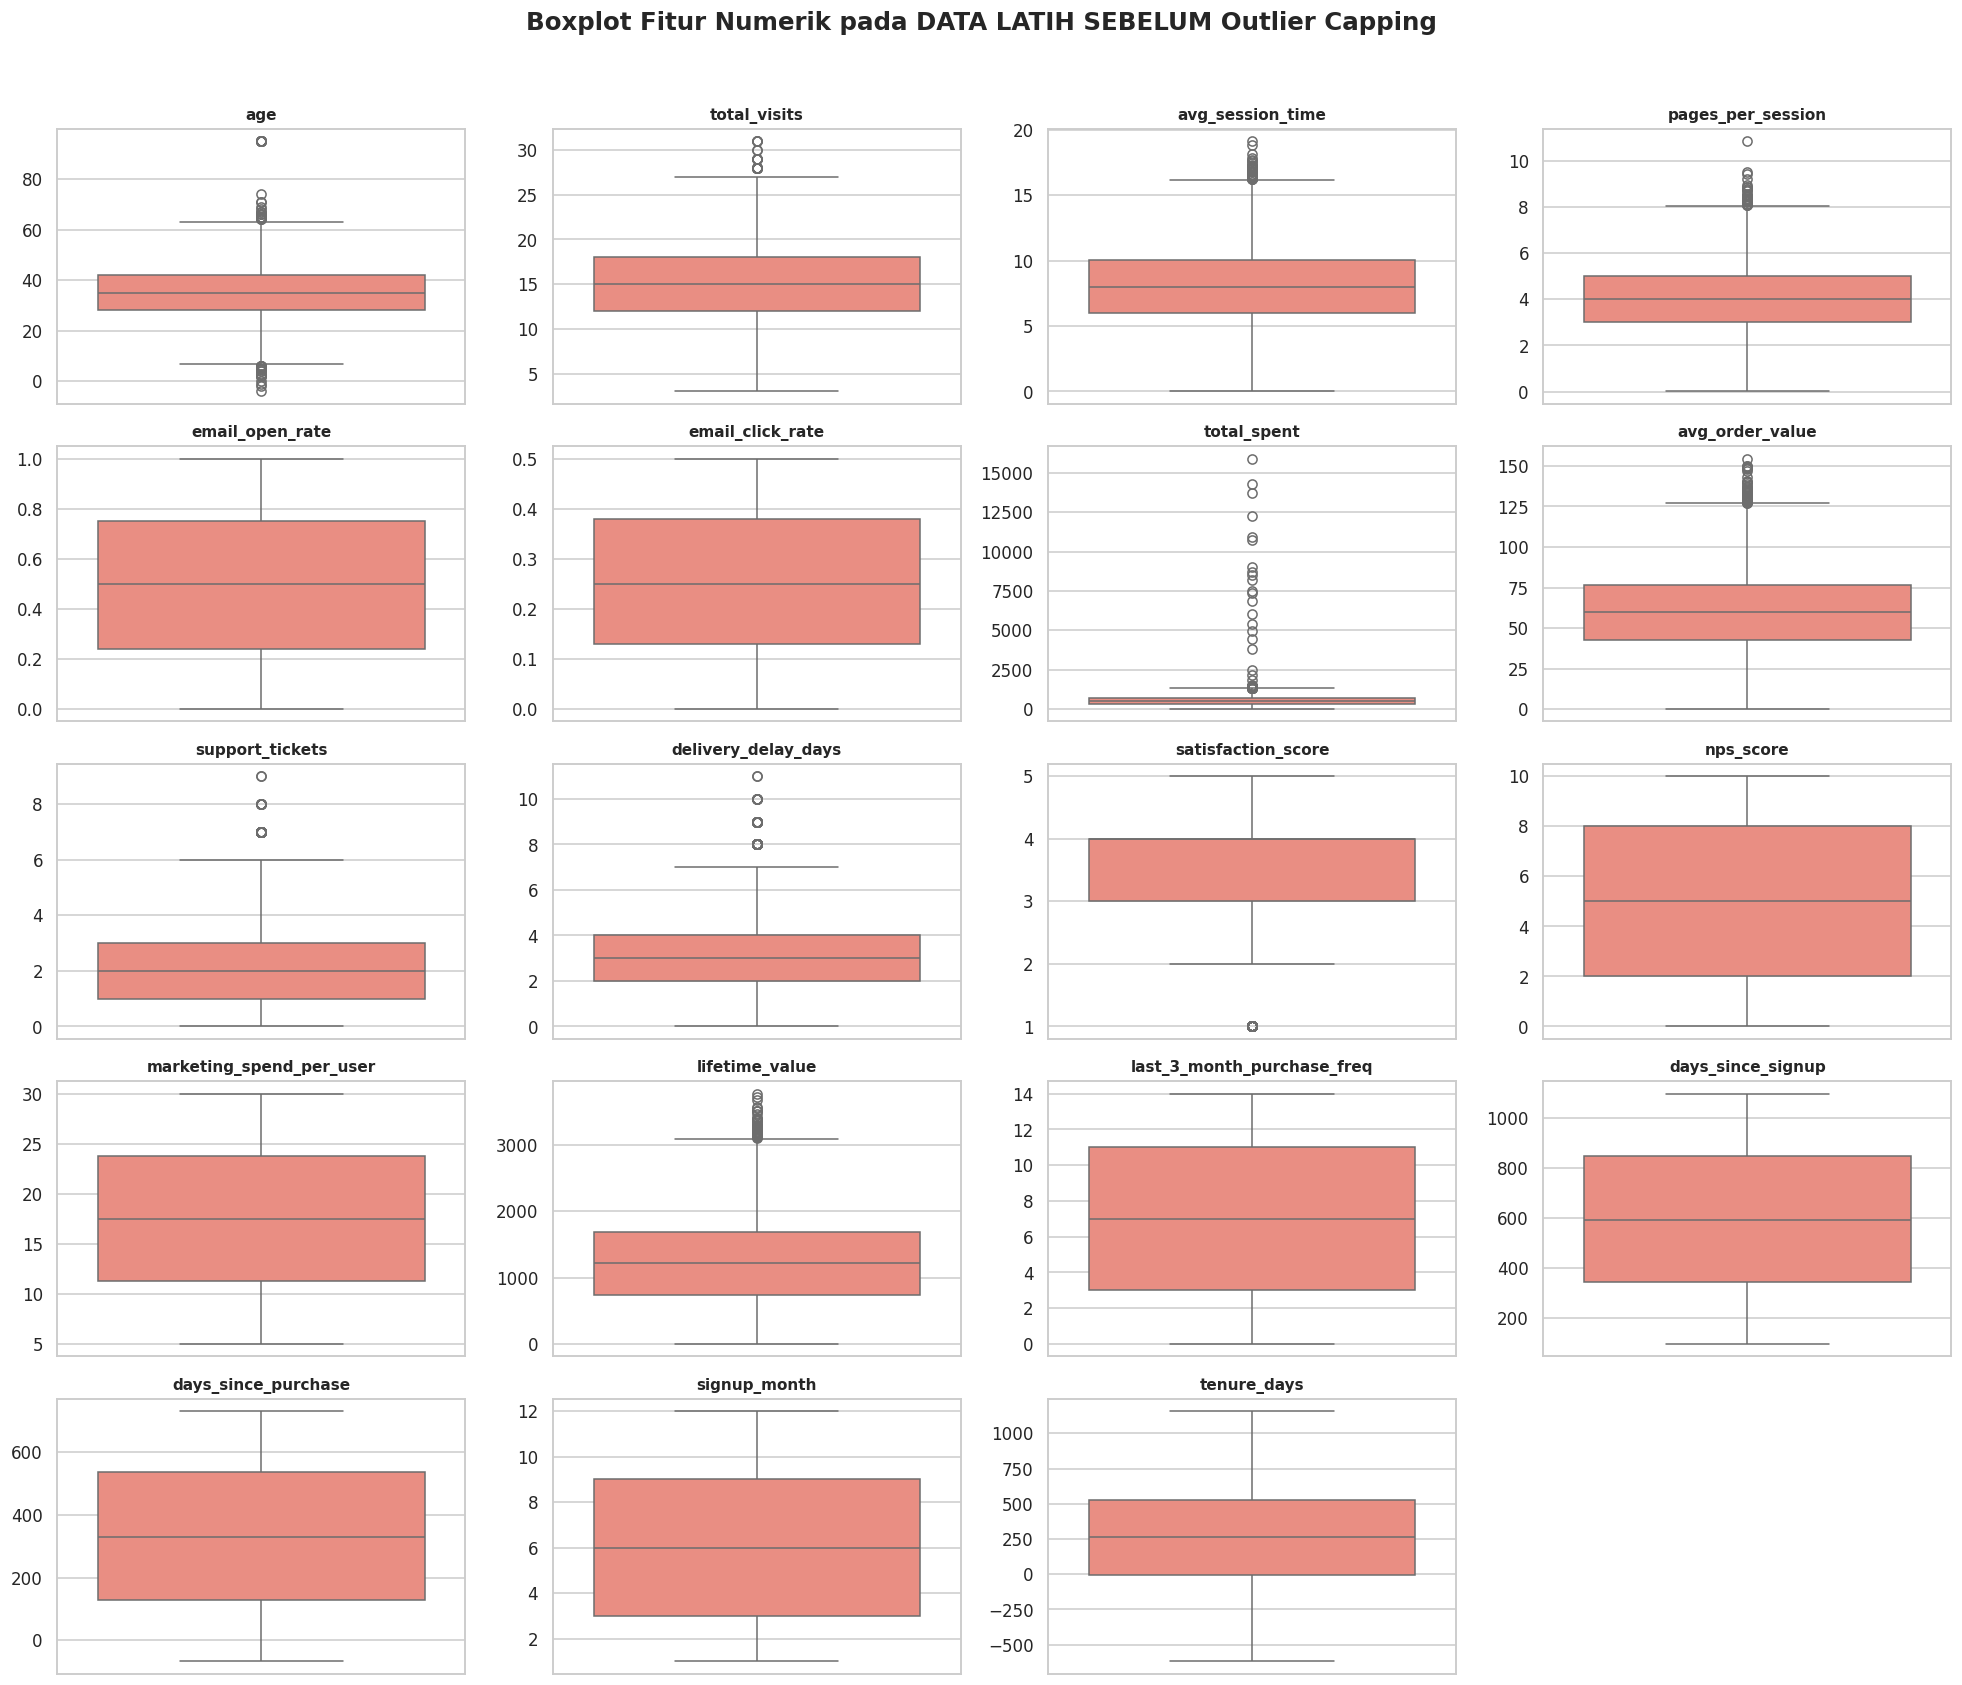

In [ ]:
# Boxplot data latih SEBELUM outlier-capping (memakai X_train_raw saja, bukan seluruh dataset)
binary_cols = ['is_premium_user', 'discount_used', 'refund_requested', 'has_coupon']
numeric_cont = [c for c in X_train_raw.select_dtypes(include=[np.number]).columns if c not in binary_cols]

plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_cont, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=X_train_raw[col], color='salmon')
    plt.title(col, fontsize=10, fontweight='bold')
    plt.ylabel('')
plt.suptitle('Boxplot Fitur Numerik pada DATA LATIH SEBELUM Outlier Capping', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# --- Outlier capping (IQR), batas dihitung HANYA dari data latih ---
iqr_bounds = {}
for col in numeric_cont:
    Q1, Q3 = X_train_raw[col].quantile(0.25), X_train_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

X_train_prep = X_train_raw.copy()
X_test_prep  = X_test_raw.copy()
outlier_count = {}
for col, (lo, hi) in iqr_bounds.items():
    outlier_count[col] = int(((X_train_prep[col] < lo) | (X_train_prep[col] > hi)).sum())
    X_train_prep[col] = X_train_prep[col].clip(lo, hi)
    X_test_prep[col]  = X_test_prep[col].clip(lo, hi)   # batas dari TRAIN diterapkan ke data uji

print('Outlier yang di-cap per kolom (batas IQR dari data latih saja):')
for k, v in sorted(outlier_count.items(), key=lambda x: -x[1]):
    if v > 0:
        print(f'  {k:<35}: {v:>5} baris')


Outlier yang di-cap per kolom (batas IQR dari data latih saja):
  satisfaction_score                 :   609 baris
  delivery_delay_days                :   148 baris
  age                                :    69 baris
  support_tickets                    :    68 baris
  total_spent                        :    61 baris
  avg_order_value                    :    50 baris
  lifetime_value                     :    43 baris
  avg_session_time                   :    37 baris
  total_visits                       :    31 baris
  pages_per_session                  :    30 baris


In [ ]:
# --- ColumnTransformer: imputasi + encoding + scaling, semuanya di-fit hanya di data latih ---
nominal_cols = ['gender', 'country', 'city', 'acquisition_channel',
                'device_type', 'subscription_type', 'payment_method']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cont),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))
    ]), nominal_cols),
    ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
], remainder='drop')

X_train_prep_arr = preprocessor.fit_transform(X_train_prep)
X_test_prep_arr  = preprocessor.transform(X_test_prep)

feature_names_prep = preprocessor.get_feature_names_out()
X_train_prep_enc = pd.DataFrame(X_train_prep_arr, columns=feature_names_prep, index=X_train_prep.index)
X_test_prep_enc  = pd.DataFrame(X_test_prep_arr,  columns=feature_names_prep, index=X_test_prep.index)

print(f'Jumlah fitur sebelum encoding : {X_train_prep.shape[1]}')
print(f'Jumlah fitur sesudah one-hot  : {X_train_prep_enc.shape[1]}')
print('\nCatatan: fitur nominal (gender, country, city, dst.) memakai One-Hot Encoding,')
print('bukan Label Encoding seperti versi lama, supaya Logistic Regression & KNN tidak')
print('salah membaca kategori sebagai angka yang berurutan/punya jarak.')


Jumlah fitur sebelum encoding : 30
Jumlah fitur sesudah one-hot  : 53

Catatan: fitur nominal (gender, country, city, dst.) memakai One-Hot Encoding,
bukan Label Encoding seperti versi lama, supaya Logistic Regression & KNN tidak
salah membaca kategori sebagai angka yang berurutan/punya jarak.


In [ ]:
lr_prep = LogisticRegression(max_iter=1000, random_state=42)
lr_prep.fit(X_train_prep_enc, y_train)
print('Model 1: Logistic Regression (Konvensional)  - selesai')

rf_prep = RandomForestClassifier(random_state=42)
rf_prep.fit(X_train_prep_enc, y_train)
print('Model 2: Random Forest (Ensemble Bagging)    - selesai')

vc_prep = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
], voting='soft')
vc_prep.fit(X_train_prep_enc, y_train)
print('Model 3: Voting Classifier (LR + RF + KNN)   - selesai')


Model 1: Logistic Regression (Konvensional)  - selesai
Model 2: Random Forest (Ensemble Bagging)    - selesai
Model 3: Voting Classifier (LR + RF + KNN)   - selesai



  Logistic Regression  [Preprocessing]
  Accuracy  : 0.8447
  Precision : 0.4805
  Recall    : 0.1609
  F1-Score  : 0.2410

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.48      0.16      0.24       460

    accuracy                           0.84      3000
   macro avg       0.67      0.56      0.58      3000
weighted avg       0.81      0.84      0.81      3000



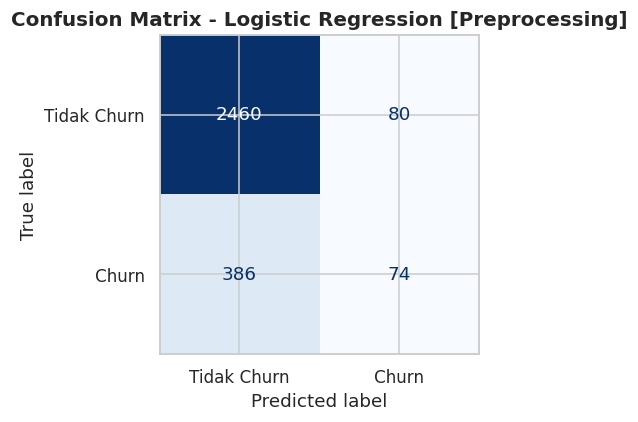


  Random Forest  [Preprocessing]
  Accuracy  : 0.8437
  Precision : 0.4727
  Recall    : 0.1696
  F1-Score  : 0.2496

              precision    recall  f1-score   support

 Tidak Churn       0.87      0.97      0.91      2540
       Churn       0.47      0.17      0.25       460

    accuracy                           0.84      3000
   macro avg       0.67      0.57      0.58      3000
weighted avg       0.81      0.84      0.81      3000



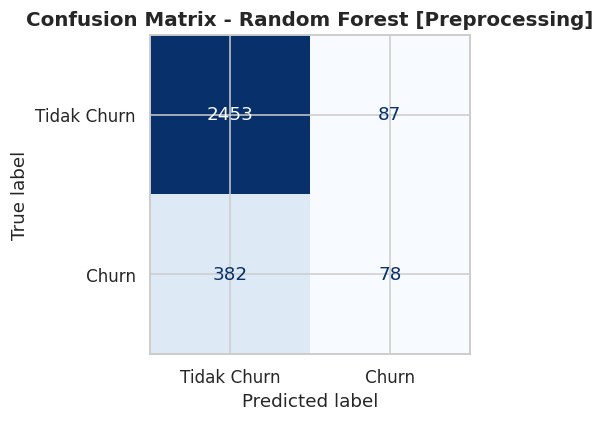


  Voting Classifier  [Preprocessing]
  Accuracy  : 0.8483
  Precision : 0.5397
  Recall    : 0.0739
  F1-Score  : 0.1300

              precision    recall  f1-score   support

 Tidak Churn       0.85      0.99      0.92      2540
       Churn       0.54      0.07      0.13       460

    accuracy                           0.85      3000
   macro avg       0.70      0.53      0.52      3000
weighted avg       0.81      0.85      0.80      3000



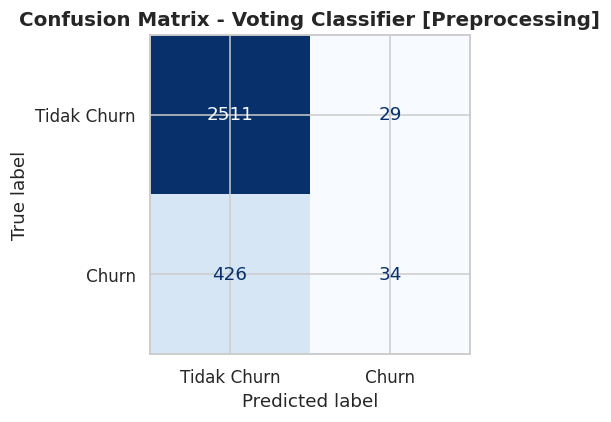

In [ ]:
results.append(evaluate_model('Logistic Regression', lr_prep, X_test_prep_enc, y_test, 'Preprocessing'))
results.append(evaluate_model('Random Forest',       rf_prep, X_test_prep_enc, y_test, 'Preprocessing'))
results.append(evaluate_model('Voting Classifier',   vc_prep, X_test_prep_enc, y_test, 'Preprocessing'))


---
## 6. Skenario 3 — Hyperparameter Tuning & Feature Selection (SMOTE Aman dari Leakage CV)

**Perbaikan utama di sini:** `SMOTE` tidak lagi diterapkan sekali ke seluruh data latih sebelum masuk
`RandomizedSearchCV`. Sebagai gantinya, `SMOTE` dibungkus bersama classifier-nya dalam satu
`imblearn.pipeline.Pipeline`. Saat `RandomizedSearchCV` melakukan cross-validation, oversampling
hanya dijalankan pada **bagian fold yang menjadi data latih internal**, sedangkan fold validasi
tetap memakai data asli (imbalanced) — sehingga skor CV yang dihasilkan jujur dan benar-benar
merepresentasikan performa pada data yang belum pernah dilihat model.


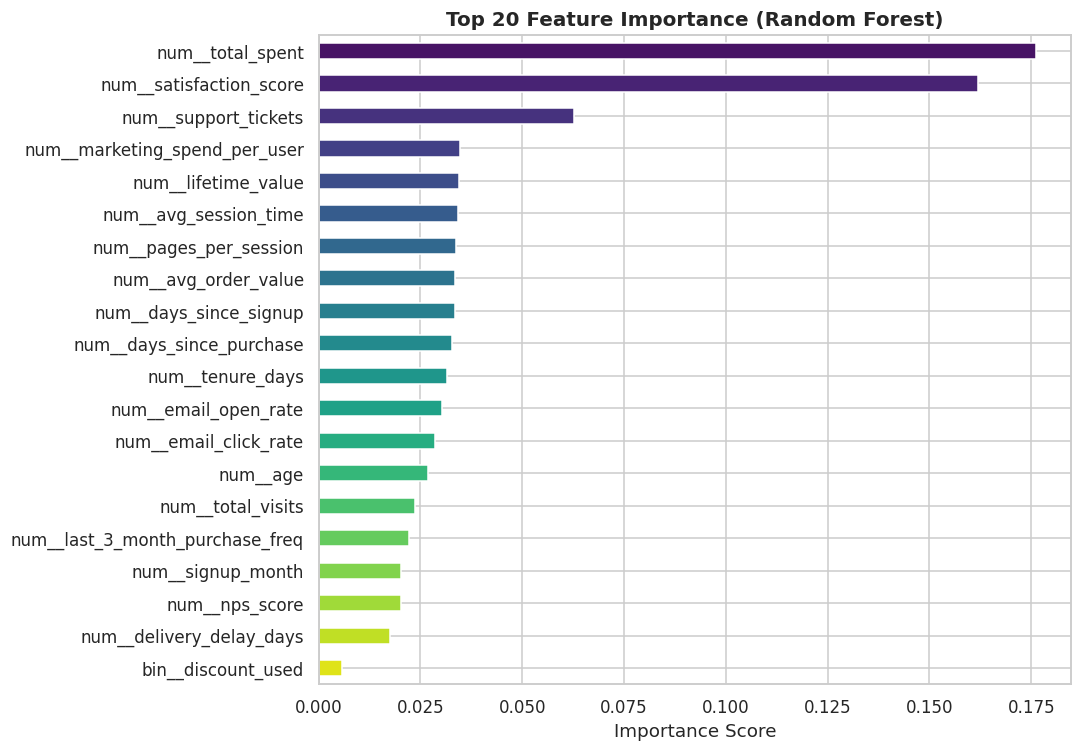

Top 15 fitur terpenting:
num__total_spent                 0.176057
num__satisfaction_score          0.162011
num__support_tickets             0.062589
num__marketing_spend_per_user    0.034700
num__lifetime_value              0.034486
num__avg_session_time            0.034328
num__pages_per_session           0.033849
num__avg_order_value             0.033602
num__days_since_signup           0.033454
num__days_since_purchase         0.032772
num__tenure_days                 0.031564
num__email_open_rate             0.030194
num__email_click_rate            0.028520
num__age                         0.026921
num__total_visits                0.023763


In [ ]:
# 6.1 Feature Importance dari Random Forest skenario Preprocessing (model dilatih HANYA di data latih)
feat_imp = pd.Series(rf_prep.feature_importances_,
                      index=X_train_prep_enc.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.head(20).plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 20))
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 15 fitur terpenting:')
print(feat_imp.head(15).to_string())


In [ ]:
TOP_N = 15
top_features = feat_imp.head(TOP_N).index.tolist()

print(f'Top {TOP_N} fitur yang dipilih untuk training:')
for i, f in enumerate(top_features, 1):
    print(f'  {i:2}. {f}')

X_train_fs = X_train_prep_enc[top_features].copy()
X_test_fs  = X_test_prep_enc[top_features].copy()

print(f'\nShape train (FS): {X_train_fs.shape}')
print(f'Shape test  (FS): {X_test_fs.shape}')


Top 15 fitur yang dipilih untuk training:
   1. num__total_spent
   2. num__satisfaction_score
   3. num__support_tickets
   4. num__marketing_spend_per_user
   5. num__lifetime_value
   6. num__avg_session_time
   7. num__pages_per_session
   8. num__avg_order_value
   9. num__days_since_signup
  10. num__days_since_purchase
  11. num__tenure_days
  12. num__email_open_rate
  13. num__email_click_rate
  14. num__age
  15. num__total_visits

Shape train (FS): (12000, 15)
Shape test  (FS): (3000, 15)


#### 6.2 Tuning Logistic Regression (SMOTE di dalam Pipeline -> CV aman)

In [ ]:
param_lr = {
    'clf__C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__solver'  : ['lbfgs', 'liblinear', 'saga'],
    'clf__max_iter': [500, 1000, 2000]
}

pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(random_state=42))
])

rs_lr = RandomizedSearchCV(
    pipe_lr, param_distributions=param_lr,
    n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rs_lr.fit(X_train_fs, y_train)   # X_train_fs MASIH imbalanced -> SMOTE jalan per-fold di dalam pipeline

print(f'\nBest Params LR: {rs_lr.best_params_}')
print(f'Best F1 (CV, sudah aman dari leakage): {rs_lr.best_score_:.4f}')
best_lr = rs_lr.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params LR: {'clf__solver': 'liblinear', 'clf__max_iter': 1000, 'clf__C': 100}
Best F1 (CV, sudah aman dari leakage): 0.4816


#### 6.3 Tuning Random Forest (SMOTE di dalam Pipeline -> CV aman)

In [ ]:
param_rf = {
    'clf__n_estimators'     : [100, 200, 300, 400],
    'clf__max_depth'        : [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'     : ['sqrt', 'log2']
}

pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42))
])

rs_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_rf,
    n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train_fs, y_train)

print(f'\nBest Params RF: {rs_rf.best_params_}')
print(f'Best F1 (CV, sudah aman dari leakage): {rs_rf.best_score_:.4f}')
best_rf = rs_rf.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params RF: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Best F1 (CV, sudah aman dari leakage): 0.6575


#### 6.4 Voting Classifier (komponen hasil tuning, treatment SMOTE konsisten dengan LR & RF)

Berbeda dari versi lama (Voting Classifier final dilatih tanpa SMOTE sementara LR & RF memakai data
ter-SMOTE), di sini Voting Classifier dibungkus `ImbPipeline` yang sama supaya perbandingan ketiga
model pada skenario Tuning benar-benar adil.


In [ ]:
best_vc = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', VotingClassifier(estimators=[
        ('lr',  best_lr.named_steps['clf']),
        ('rf',  best_rf.named_steps['clf']),
        ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    ], voting='soft'))
])
best_vc.fit(X_train_fs, y_train)
print('Voting Classifier (komponen hasil tuning, SMOTE konsisten) selesai dilatih.')


Voting Classifier (komponen hasil tuning, SMOTE konsisten) selesai dilatih.



  Logistic Regression  [Tuning]
  Accuracy  : 0.7530
  Precision : 0.3523
  Recall    : 0.7283
  F1-Score  : 0.4748

              precision    recall  f1-score   support

 Tidak Churn       0.94      0.76      0.84      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.65      0.74      0.66      3000
weighted avg       0.85      0.75      0.78      3000



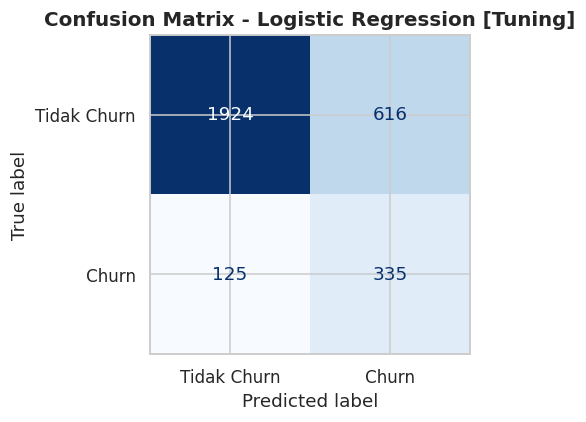


  Random Forest  [Tuning]
  Accuracy  : 0.8560
  Precision : 0.5161
  Recall    : 0.9739
  F1-Score  : 0.6747

              precision    recall  f1-score   support

 Tidak Churn       0.99      0.83      0.91      2540
       Churn       0.52      0.97      0.67       460

    accuracy                           0.86      3000
   macro avg       0.76      0.90      0.79      3000
weighted avg       0.92      0.86      0.87      3000



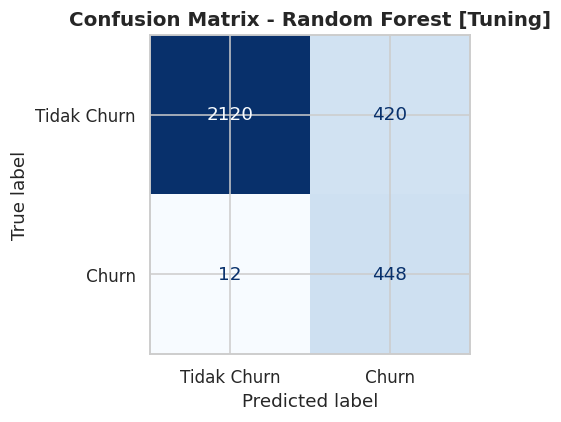


  Voting Classifier  [Tuning]
  Accuracy  : 0.8370
  Precision : 0.4824
  Recall    : 0.8652
  F1-Score  : 0.6195

              precision    recall  f1-score   support

 Tidak Churn       0.97      0.83      0.90      2540
       Churn       0.48      0.87      0.62       460

    accuracy                           0.84      3000
   macro avg       0.73      0.85      0.76      3000
weighted avg       0.90      0.84      0.85      3000



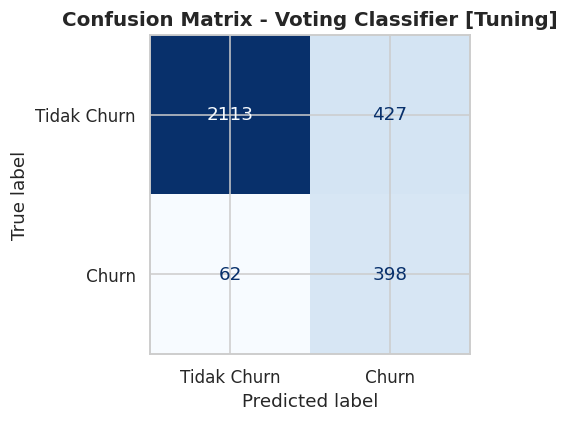

In [ ]:
results.append(evaluate_model('Logistic Regression', best_lr, X_test_fs, y_test, 'Tuning'))
results.append(evaluate_model('Random Forest',       best_rf, X_test_fs, y_test, 'Tuning'))
results.append(evaluate_model('Voting Classifier',   best_vc, X_test_fs, y_test, 'Tuning'))


---
## 7. Rekap dan Perbandingan Semua 9 Model

In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(['Skenario', 'F1-Score'],
                                     ascending=[True, False]).reset_index(drop=True)

display(df_results.style
        .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='YlGn')
        .format({
            'Accuracy': '{:.4f}',
            'Precision': '{:.4f}',
            'Recall': '{:.4f}',
            'F1-Score': '{:.4f}'
        }))


,Model,Skenario,Accuracy,Precision,Recall,F1-Score
0,Random Forest,Direct,0.8510,0.5230,0.3217,0.3984
1,Logistic Regression,Direct,0.8467,0.5000,0.1413,0.2203
2,Voting Classifier,Direct,0.8480,0.5233,0.0978,0.1648
3,Random Forest,Preprocessing,0.8437,0.4727,0.1696,0.2496
4,Logistic Regression,Preprocessing,0.8447,0.4805,0.1609,0.2410
5,Voting Classifier,Preprocessing,0.8483,0.5397,0.0739,0.1300
6,Random Forest,Tuning,0.8560,0.5161,0.9739,0.6747
7,Voting Classifier,Tuning,0.8370,0.4824,0.8652,0.6195
8,Logistic Regression,Tuning,0.7530,0.3523,0.7283,0.4748


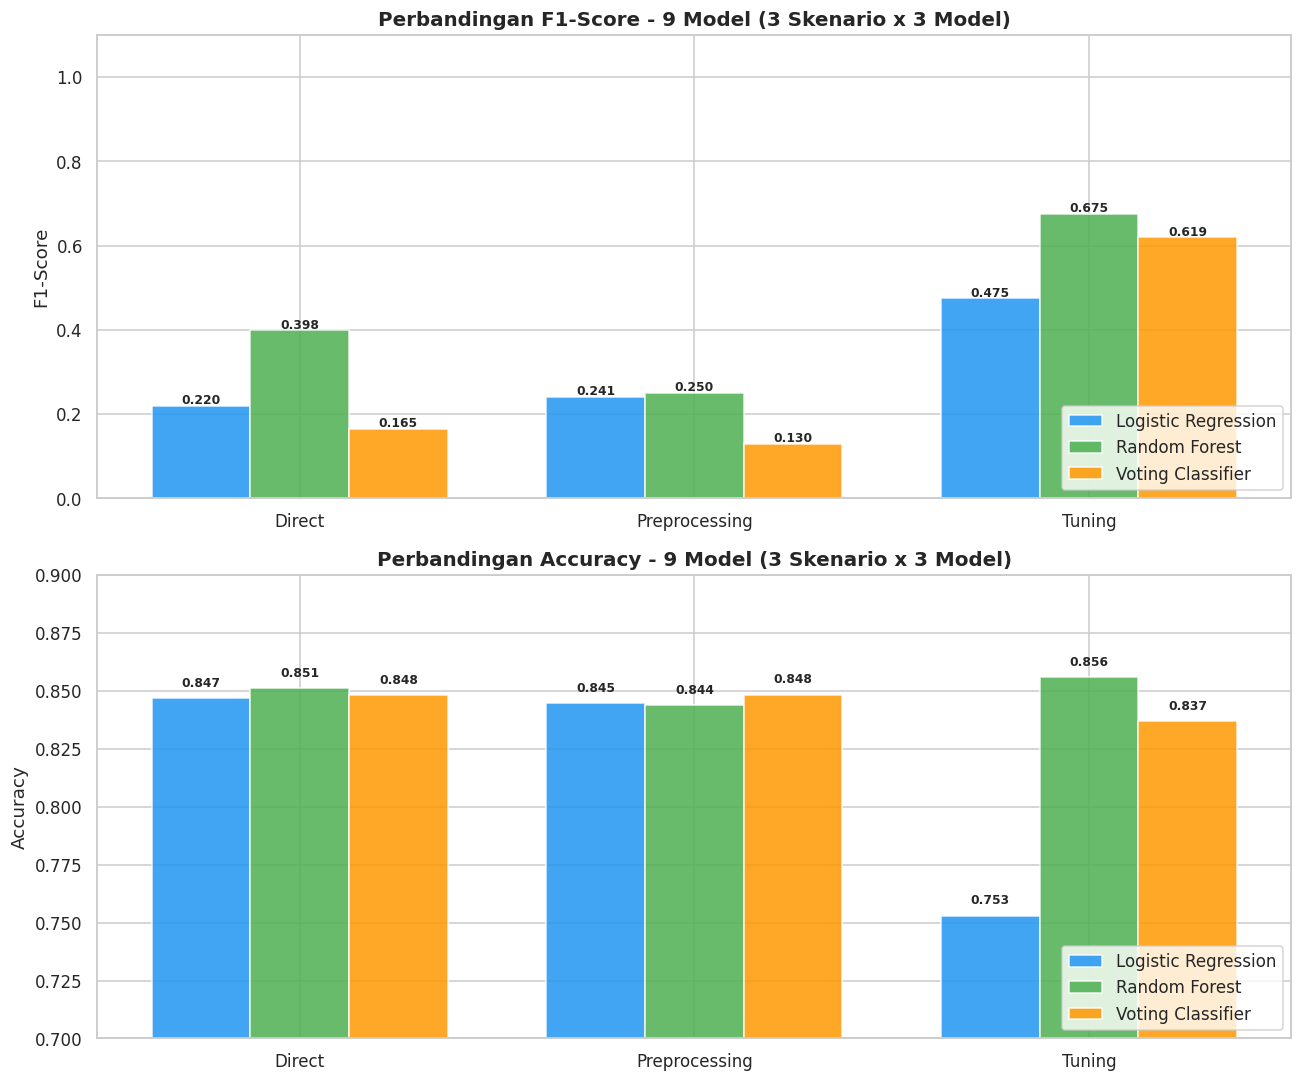

In [ ]:
skenarios   = ['Direct', 'Preprocessing', 'Tuning']
models_list = ['Logistic Regression', 'Random Forest', 'Voting Classifier']
colors      = ['#2196F3', '#4CAF50', '#FF9800']
metrics     = ['F1-Score', 'Accuracy']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
x = np.arange(len(skenarios))
width = 0.25

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for i, (model, color) in enumerate(zip(models_list, colors)):
        vals = []
        for sk in skenarios:
            row = df_results.loc[(df_results['Model']==model) & (df_results['Skenario']==sk)]
            vals.append(row[metric].values[0] if len(row) > 0 else 0)

        bars = ax.bar(x + i*width, vals, width=width, label=model,
                      color=color, alpha=0.85, edgecolor='white')

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels(skenarios, fontsize=11)
    ax.set_ylabel(metric)
    ax.set_title(f'Perbandingan {metric} - 9 Model (3 Skenario x 3 Model)',
                 fontweight='bold', fontsize=13)
    ax.legend(loc='lower right')

    # Penyesuaian rentang agar perbedaan akurasi lebih terlihat
    if metric == 'Accuracy':
        ax.set_ylim(0.7, 0.9)  # Zoom in ke area 70% - 90%
    else:
        ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
best_row = df_results.loc[df_results['F1-Score'].idxmax()]
print('=' * 45)
print('  MODEL TERBAIK')
print('=' * 45)
print(f'  Model    : {best_row["Model"]}')
print(f'  Skenario : {best_row["Skenario"]}')
print(f'  Accuracy : {best_row["Accuracy"]:.4f}')
print(f'  Precision: {best_row["Precision"]:.4f}')
print(f'  Recall   : {best_row["Recall"]:.4f}')
print(f'  F1-Score : {best_row["F1-Score"]:.4f}')


  MODEL TERBAIK
  Model    : Random Forest
  Skenario : Tuning
  Accuracy : 0.8560
  Precision: 0.5161
  Recall   : 0.9739
  F1-Score : 0.6747


### Analisis Hubungan Satisfaction Score vs Churn
Untuk menjawab mengapa hasil di Streamlit terasa terbalik, kita perlu melihat distribusi asli data latih dan pengaruh fitur tersebut pada model.

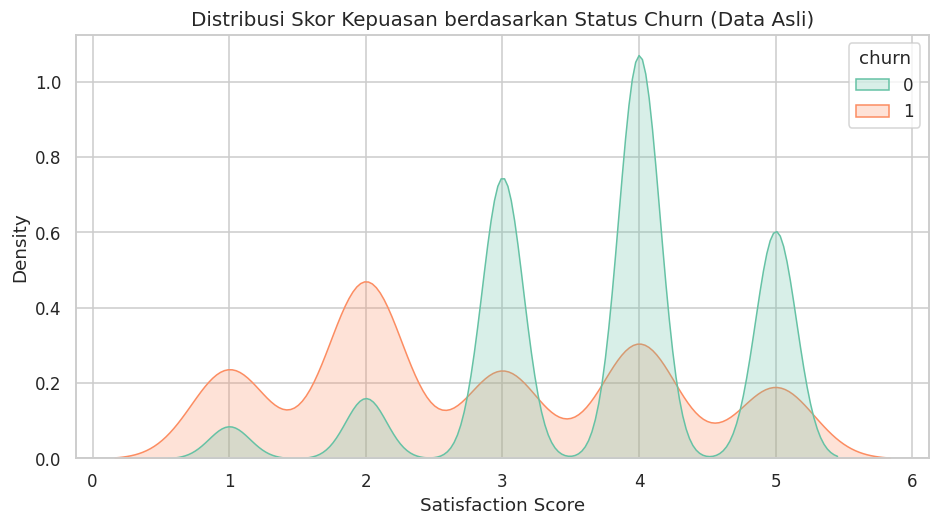

Korelasi Pearson antara Satisfaction dan Churn: -0.3036

Analisis Model Logistic Regression:


,Feature,Coefficient
1,num__satisfaction_score,-1.141743


Interpretasi: Koefisien Negatif. Semakin TINGGI satisfaction, semakin RENDAH peluang churn (Sesuai Logika).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisasi Distribusi Satisfaction vs Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='satisfaction_score', hue='churn', fill=True, common_norm=False)
plt.title('Distribusi Skor Kepuasan berdasarkan Status Churn (Data Asli)')
plt.xlabel('Satisfaction Score')
plt.ylabel('Density')
plt.show()

# 2. Cek Korelasi Linear
correlation = df[['satisfaction_score', 'churn']].corr().iloc[0, 1]
print(f'Korelasi Pearson antara Satisfaction dan Churn: {correlation:.4f}')

# 3. Cek Koefisien Logistic Regression (jika menggunakan Tuning/FS)
if 'best_lr' in globals():
    # Ambil koefisien untuk fitur satisfaction
    lr_model = best_lr.named_steps['clf']
    coef_df = pd.DataFrame({
        'Feature': top_features,
        'Coefficient': lr_model.coef_[0]
    }).sort_values(by='Coefficient')

    sat_coef = coef_df[coef_df['Feature'].str.contains('satisfaction')]
    print('\nAnalisis Model Logistic Regression:')
    display(sat_coef)

    if not sat_coef.empty and sat_coef['Coefficient'].values[0] < 0:
        print('Interpretasi: Koefisien Negatif. Semakin TINGGI satisfaction, semakin RENDAH peluang churn (Sesuai Logika).')
    else:
        print('Interpretasi: Koefisien Positif. Semakin TINGGI satisfaction, semakin TINGGI peluang churn (Terbalik/Aneh).')

---
## 8. Persiapan Deployment

Artefak yang disimpan kini berisi **satu `ColumnTransformer` terpadu** (imputasi + one-hot + scaling,
hasil fit dari data latih) ditambah batas IQR data latih, bukan kombinasi `label_encoders` + `scaler`
terpisah seperti sebelumnya. Untuk model dari skenario *Tuning*, `model.predict()` otomatis melewati
langkah SMOTE saat inferensi (properti `imblearn.Pipeline`: sampler hanya aktif saat `.fit()`).

> Karena struktur fitur berubah (one-hot + seleksi top-15 fitur untuk skenario Tuning), bagian
> `app.py` Streamlit pada notebook lama **perlu disesuaikan**: input mentah dari form harus melewati
> `iqr_bounds` (clip) -> `preprocessor.transform()` -> (jika model dari skenario Tuning) seleksi
> `top_features`, baru kemudian `model.predict()`. Beri tahu saya jika Anda ingin saya tuliskan ulang
> `app.py` sesuai struktur baru ini.


In [ ]:
model_map = {
    ('Logistic Regression', 'Tuning')        : best_lr,
    ('Random Forest',       'Tuning')        : best_rf,
    ('Voting Classifier',   'Tuning')        : best_vc,
    ('Logistic Regression', 'Preprocessing') : lr_prep,
    ('Random Forest',       'Preprocessing') : rf_prep,
    ('Voting Classifier',   'Preprocessing') : vc_prep,
    ('Logistic Regression', 'Direct')        : lr_direct,
    ('Random Forest',       'Direct')        : rf_direct,
    ('Voting Classifier',   'Direct')        : vc_direct,
}

key = (best_row['Model'], best_row['Skenario'])
best_model_obj = model_map.get(key, best_rf)

artifacts = {
    'model'         : best_model_obj,
    'preprocessor'  : preprocessor,          # ColumnTransformer (imputasi + one-hot + scaling), fit di train
    'iqr_bounds'    : iqr_bounds,            # batas outlier IQR dari data latih
    'top_features'  : top_features,          # hanya dipakai jika model terbaik berasal dari skenario Tuning
    'raw_columns'   : list(X_raw.columns),   # urutan kolom mentah sebelum preprocessing
    'numeric_cont'  : numeric_cont,
    'model_name'    : best_row['Model'],
    'scenario'      : best_row['Skenario'],
}

joblib.dump(artifacts, 'churn_model.joblib')
print(f'Model tersimpan: churn_model.joblib')
print(f'Ukuran         : {os.path.getsize("churn_model.joblib") / 1024:.1f} KB')
print(f'Model terbaik  : {best_row["Model"]} - Skenario {best_row["Skenario"]}')


Model tersimpan: churn_model.joblib
Ukuran         : 15619.9 KB
Model terbaik  : Random Forest - Skenario Tuning


In [ ]:
req = """streamlit==1.40.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.5.3
matplotlib==3.9.0
seaborn==0.13.2
imbalanced-learn==0.14.2
"""
with open('requirements.txt', 'w') as f:
    f.write(req)
print('requirements.txt berhasil dibuat.')
print(req)


requirements.txt berhasil dibuat.
streamlit==1.40.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.5.3
matplotlib==3.9.0
seaborn==0.13.2
imbalanced-learn==0.14.2



### 8.2 Ekspor `app.py` untuk Streamlit

Sel berikut menulis `app.py` secara otomatis dan (di Colab) langsung men-*download*-nya.
Kumpulkan tiga file ini untuk deployment:
- `churn_model.joblib` — artefak model
- `requirements.txt` — dependensi Python
- `app.py` — aplikasi Streamlit


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Sel ini mengekspor app.py untuk deployment Streamlit.
# Jalankan sel ini setelah training selesai, lalu download app.py
# bersama churn_model.joblib dan requirements.txt ke Streamlit Cloud.
# ─────────────────────────────────────────────────────────────────────────────

_app_py_content = r'''"""
app.py — Strategic Customer Churn Dashboard (Streamlit)
Kompatibel dengan artefak dari UAS_Churn_Prediction_v2.ipynb
"""

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import date

# ── Konfigurasi Halaman ───────────────────────────────────────────────────────
st.set_page_config(
    page_title="Strategic Churn Dashboard",
    page_icon="🔮",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── CSS Kustom (Tema Gelap Eksekutif) ─────────────────────────────────────────
st.markdown("""
<style>
    /* Global Background & Fonts */
    .stApp {
        background-color: #0E1117;
        color: #F8FAFC;
    }

    /* Metric Cards */
    .metric-card {
        background: linear-gradient(135deg, #1E293B 0%, #0F172A 100%);
        padding: 24px;
        border-radius: 12px;
        text-align: center;
        margin-bottom: 16px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.3);
        border: 1px solid #334155;
    }
    .metric-label { font-size: 14px; opacity: 0.7; margin-bottom: 4px; font-weight: 600; color: #CBD5E1; }
    .metric-value { font-size: 32px; font-weight: 800; color: #38BDF8; }

    /* Specific Churn Cards */
    .churn-high {
        background: linear-gradient(135deg, #450A0A 0%, #2A0404 100%);
        border-color: #7F1D1D;
    }
    .churn-high .metric-value { color: #F87171; }

    .churn-low  {
        background: linear-gradient(135deg, #064E3B 0%, #022C22 100%);
        border-color: #065F46;
    }
    .churn-low .metric-value { color: #34D399; }

    /* Headers & Typography */
    .section-header {
        font-size: 18px;
        font-weight: 600;
        color: #E2E8F0;
        border-left: 4px solid #38BDF8;
        padding-left: 12px;
        margin: 24px 0 16px;
        background-color: #1E293B;
        padding-top: 8px;
        padding-bottom: 8px;
        border-radius: 4px;
    }
</style>
""", unsafe_allow_html=True)


# ── Load Artefak ──────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="Memuat model…")
def load_artifacts(path: str = "churn_model.joblib"):
    if not os.path.exists(path):
        return None
    return joblib.load(path)

artifacts = load_artifacts()

# ── Konstanta Referensi ───────────────────────────────────────────────────────
REF_DATE = pd.Timestamp("2025-01-01")


# ── Feature Engineering ───────────────────────────────────────────────────────
def process_input_data(raw_data, raw_columns):
    df = pd.DataFrame([raw_data])

    # Konversi tipe data tanggal
    signup_ts = pd.to_datetime(df["signup_date"])
    purchase_ts = pd.to_datetime(df["last_purchase_date"])

    # Feature engineering turunan
    df["days_since_signup"] = (REF_DATE - signup_ts).dt.days
    df["days_since_purchase"] = (REF_DATE - purchase_ts).dt.days
    df["signup_month"] = signup_ts.dt.month
    df["tenure_days"] = (purchase_ts - signup_ts).dt.days

    # Cek kupon
    df["has_coupon"] = df["coupon_code"].apply(lambda x: 0 if pd.isna(x) or x == "" else 1)

    # Pastikan semua kolom yang dibutuhkan model tersedia
    if raw_columns is not None:
        for col in raw_columns:
            if col not in df.columns:
                df[col] = 0

        # Saring hanya kolom yang ada di raw_columns
        available_cols = [c for c in raw_columns if c in df.columns]
        return df[available_cols]

    return df


# ── Full Prediction Pipeline ──────────────────────────────────────────────────
def run_prediction(input_df, artifacts):
    model        = artifacts["model"]
    preprocessor = artifacts["preprocessor"]
    iqr_bounds   = artifacts.get("iqr_bounds", {})
    top_features = artifacts.get("top_features", [])
    scenario     = artifacts.get("scenario", "Full")

    df = input_df.copy()

    # 1. Outlier clipping (batas IQR)
    for col, (lo, hi) in iqr_bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)

    # 2. Impute + OHE + scale
    X_arr      = preprocessor.transform(df)
    feat_names = preprocessor.get_feature_names_out()
    X_enc      = pd.DataFrame(X_arr, columns=feat_names)

    # 3. Seleksi top features
    if scenario == "Tuning" and len(top_features) > 0:
        available = [f for f in top_features if f in X_enc.columns]
        X_enc = X_enc[available]

    # 4. Prediksi
    pred  = model.predict(X_enc)[0]
    proba = (model.predict_proba(X_enc)[0][1]
             if hasattr(model, "predict_proba") else float(pred))
    return int(pred), float(proba)


# ═════════════════════════════════════════════════════════════════════════════
# MAIN UI
# ═════════════════════════════════════════════════════════════════════════════

# ── Sidebar ───────────────────────────────────────────────────────────────────
with st.sidebar:
    st.title("🔮 Churn Predictor")
    st.caption("Strategic Customer Analysis Dashboard")
    st.divider()
    if artifacts:
        st.markdown("### 📦 Info Model")
        n_feat = (str(len(artifacts.get("top_features", [])))
                  if artifacts.get("scenario") == "Tuning" else "Semua")
        st.success(
            f"**Model:** {artifacts.get('model_name', '-')}\n\n"
            f"**Skenario:** {artifacts.get('scenario', '-')}\n\n"
            f"**Fitur Prediktor:** {n_feat}"
        )
    else:
        st.warning("⚠️ `churn_model.joblib` tidak ditemukan.")
    st.divider()
    st.caption("© 2026 · Business & Tech Analytics")


# ── Header ────────────────────────────────────────────────────────────────────
st.title("🛡️ Predictive Customer Churn")
st.markdown("Input data interaksi dan finansial klien untuk mengevaluasi probabilitas churn dan menentukan langkah eskalasi sales selanjutnya.")
if artifacts is None:
    st.error("❌ File model `churn_model.joblib` belum ada di direktori yang sama.")
    st.stop()

raw_columns = artifacts.get("raw_columns", [])

# ── Form Berdasarkan Kolom CSV Asli (Vertikal / No Tabs) ──────────────────────
with st.form("form_prediksi"):

    # --- SECTION 1: Demografi & Wilayah ---
    st.markdown('<p class="section-header">🧑‍💼 Identitas & Wilayah</p>', unsafe_allow_html=True)
    c1, c2, c3, c4 = st.columns(4)
    gender  = c1.selectbox("Gender", ["Male", "Female", "Other"])
    age     = c2.number_input("Age", min_value=10, max_value=100, value=30)
    country = c3.text_input("Country", value="UK")
    city    = c4.text_input("City", value="London")

    # --- SECTION 2: Informasi Langganan ---
    st.markdown('<p class="section-header">📅 Informasi Langganan</p>', unsafe_allow_html=True)
    c5, c6, c7, c8 = st.columns(4)
    signup_date        = c5.date_input("Signup Date", value=date(2023, 1, 15))
    last_purchase_date = c6.date_input("Last Purchase Date", value=date(2024, 6, 1))
    subscription_type  = c7.selectbox("Subscription Type", ["Monthly", "Annual", "Basic"])
    is_premium_user    = c8.selectbox("Is Premium User?", [1, 0], format_func=lambda x: "Yes (1)" if x==1 else "No (0)")

    # --- SECTION 3: Sumber Akuisisi & Perangkat ---
    st.markdown('<p class="section-header">📱 Sumber Akuisisi & Perangkat</p>', unsafe_allow_html=True)
    c9, c10, c11 = st.columns([2, 2, 1])
    acquisition_channel = c9.selectbox("Acquisition Channel", ["Organic", "Email", "Facebook Ads", "Google Ads", "Referral"])
    device_type         = c10.selectbox("Device Type", ["Desktop", "Mobile", "Tablet"])

    # --- SECTION 4: Metrik Interaksi Web/Aplikasi ---
    st.markdown('<p class="section-header">🌐 Metrik Interaksi Web/Aplikasi</p>', unsafe_allow_html=True)
    c12, c13, c14 = st.columns(3)
    total_visits      = c12.number_input("Total Visits", min_value=0, value=10)
    avg_session_time  = c13.number_input("Avg Session Time (mins)", min_value=0.0, value=5.5, format="%.2f")
    pages_per_session = c14.number_input("Pages per Session", min_value=0.0, value=3.2, format="%.2f")

    # --- SECTION 5: Metrik Email & Kepuasan ---
    st.markdown('<p class="section-header">⭐ Metrik Email & Kepuasan</p>', unsafe_allow_html=True)
    c15, c16, c17, c18 = st.columns(4)
    email_open_rate    = c15.number_input("Email Open Rate", min_value=0.0, max_value=1.0, value=0.45, format="%.2f")
    email_click_rate   = c16.number_input("Email Click Rate", min_value=0.0, max_value=1.0, value=0.15, format="%.2f")
    satisfaction_score = c17.number_input("Satisfaction Score", min_value=0, max_value=5, value=4)
    nps_score          = c18.number_input("NPS Score", min_value=0, max_value=10, value=8)

    # --- SECTION 6: Finansial & Transaksi ---
    st.markdown('<p class="section-header">💳 Finansial & Transaksi</p>', unsafe_allow_html=True)
    c19, c20, c21, c22 = st.columns(4)
    total_spent                = c19.number_input("Total Spent ($)", min_value=0.0, value=1250.50, format="%.2f")
    avg_order_value            = c20.number_input("Avg Order Value ($)", min_value=0.0, value=85.20, format="%.2f")
    lifetime_value             = c21.number_input("Lifetime Value ($)", min_value=0.0, value=1500.00, format="%.2f")
    last_3_month_purchase_freq = c22.number_input("Last 3 Month Freq", min_value=0, value=2)

    # --- SECTION 7: Layanan & Promo ---
    st.markdown('<p class="section-header">🛍️ Layanan & Promo</p>', unsafe_allow_html=True)
    c23, c24, c25 = st.columns(3)
    payment_method      = c23.selectbox("Payment Method", ["Card", "PayPal", "UPI", "Bank Transfer"])
    discount_used       = c24.selectbox("Discount Used?", [1, 0], format_func=lambda x: "Yes (1)" if x==1 else "No (0)")
    coupon_code         = c25.text_input("Coupon Code", placeholder="Kosongkan jika tidak ada (opsional)")

    c26, c27, c28, c29 = st.columns(4)
    support_tickets          = c26.number_input("Support Tickets", min_value=0, value=1)
    refund_requested         = c27.selectbox("Refund Requested?", [1, 0], format_func=lambda x: "Yes (1)" if x==1 else "No (0)")
    delivery_delay_days      = c28.number_input("Delivery Delay Days", min_value=0, value=0)
    marketing_spend_per_user = c29.number_input("Marketing Spend ($)", min_value=0.0, value=25.50, format="%.2f")

    st.markdown("<br>", unsafe_allow_html=True)
    submitted = st.form_submit_button("⚡ Eksekusi Prediksi Churn", type="primary", use_container_width=True)


# ── Eksekusi Prediksi ─────────────────────────────────────────────────────────
if submitted:
    if last_purchase_date < signup_date:
        st.error("❌ Last Purchase Date tidak boleh mendahului Signup Date.")
        st.stop()

    # Data dictionary sesuai kolom CSV
    raw_data_input = {
        "gender": gender,
        "age": age,
        "country": country,
        "city": city,
        "signup_date": signup_date,
        "last_purchase_date": last_purchase_date,
        "acquisition_channel": acquisition_channel,
        "device_type": device_type,
        "subscription_type": subscription_type,
        "is_premium_user": is_premium_user,
        "total_visits": total_visits,
        "avg_session_time": avg_session_time,
        "pages_per_session": pages_per_session,
        "email_open_rate": email_open_rate,
        "email_click_rate": email_click_rate,
        "total_spent": total_spent,
        "avg_order_value": avg_order_value,
        "discount_used": discount_used,
        "coupon_code": coupon_code,
        "support_tickets": support_tickets,
        "refund_requested": refund_requested,
        "delivery_delay_days": delivery_delay_days,
        "payment_method": payment_method,
        "satisfaction_score": satisfaction_score,
        "nps_score": nps_score,
        "marketing_spend_per_user": marketing_spend_per_user,
        "lifetime_value": lifetime_value,
        "last_3_month_purchase_freq": last_3_month_purchase_freq
    }

    with st.spinner("Mengalkulasi proyeksi probabilitas..."):
        input_df = process_input_data(raw_data_input, raw_columns)
        pred, proba_churn = run_prediction(input_df, artifacts)

    # ── Tampilan Hasil ────────────────────────────────────────────────────────
    st.divider()
    st.subheader("📊 Hasil Prediksi Analisis")

    is_churn   = pred == 1
    card_class = "churn-high" if is_churn else "churn-low"
    verdict    = "🚨 RISIKO CHURN" if is_churn else "✅ AMAN (RETENSI)"
    risk_label = ("🔴 Kritis" if proba_churn > 0.70 else
                  "🟡 Waspada" if proba_churn > 0.40 else "🟢 Terkendali")

    r1, r2, r3 = st.columns(3)
    r1.markdown(
        f'<div class="metric-card {card_class}">'
        f'<div class="metric-label">Proyeksi Pelanggan</div>'
        f'<div class="metric-value">{verdict}</div></div>',
        unsafe_allow_html=True)
    r2.markdown(
        f'<div class="metric-card">'
        f'<div class="metric-label">Probabilitas Churn</div>'
        f'<div class="metric-value">{proba_churn:.1%}</div></div>',
        unsafe_allow_html=True)
    r3.markdown(
        f'<div class="metric-card">'
        f'<div class="metric-label">Status Risiko</div>'
        f'<div class="metric-value">{risk_label}</div></div>',
        unsafe_allow_html=True)

    # Visualisasi Bar / Gauge
    st.markdown("**Pemetaan Skala Risiko**")
    fig, ax = plt.subplots(figsize=(8, 1.2))
    fig.patch.set_facecolor('#0E1117')
    ax.set_facecolor('#0E1117')

    ax.barh([""], [1], color="#1E293B", height=0.4, edgecolor="#334155")
    bar_color = ("#EF4444" if proba_churn > 0.70 else
                 "#F59E0B" if proba_churn > 0.40 else "#10B981")
    ax.barh([""], [proba_churn], color=bar_color, height=0.4)
    ax.set_xlim(0, 1)

    ax.axvline(0.4, color="#FBBF24", linewidth=1.5, linestyle=":", alpha=0.7)
    ax.axvline(0.7, color="#F87171", linewidth=1.5, linestyle=":", alpha=0.7)

    ax.text(min(proba_churn + 0.02, 0.92), 0,
            f"{proba_churn:.1%}", va="center", fontweight="bold", fontsize=11, color="#F8FAFC")

    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="y", left=False)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)

    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

    # Expanders untuk Debugging
    with st.expander("📋 Log Data Input (Setelah Feature Engineering)"):
        st.dataframe(input_df.T.rename(columns={0: "Value"}), use_container_width=True)
'''

with open('app.py', 'w', encoding='utf-8') as _f:
    _f.write(_app_py_content)

import os as _os
_size = _os.path.getsize('app.py') / 1024
print(f'✅ app.py berhasil ditulis: {_size:.1f} KB')
print(f'   Baris kode: {_app_py_content.count(chr(10))}')
print()
print('📂 File yang siap untuk deployment:')
for _fn in ['churn_model.joblib', 'requirements.txt', 'app.py']:
    _e = _os.path.exists(_fn)
    _s = f"{_os.path.getsize(_fn)/1024:.1f} KB" if _e else 'BELUM ADA'
    _status = '✅' if _e else '❌'
    print(f'  {_status}  {_fn:<35} {_s}')

# Download di Google Colab (opsional)
try:
    from google.colab import files
    files.download('app.py')
    print()
    print('⬇️  app.py sedang didownload...')
except ImportError:
    print()
    print('ℹ️  Bukan environment Colab — ambil app.py langsung dari file explorer.')

In [ ]:
files_needed = ['churn_model.joblib', 'app.py', 'requirements.txt']
print('Checklist File Deployment:')
print('-' * 50)
for fn in files_needed:
    exists = os.path.exists(fn)
    status = '[OK]' if exists else '[--]'
    size   = f'{os.path.getsize(fn)/1024:.1f} KB' if exists else '-'
    print(f'  {status}  {fn:<35} {size}')
print()
print('Langkah Deployment ke Streamlit Cloud:')
print('  1. Push semua file ke GitHub repository')
print('  2. Login ke https://share.streamlit.io')
print('  3. Buat app baru -> pilih repo -> main file: app.py')
print('  4. Klik Deploy dan tunggu selesai')
print('  5. Akses URL publik yang diberikan Streamlit Cloud')


Checklist File Deployment:
--------------------------------------------------
  [OK]  churn_model.joblib                  15619.9 KB
  [OK]  app.py                              17.5 KB
  [OK]  requirements.txt                    0.1 KB

Langkah Deployment ke Streamlit Cloud:
  1. Push semua file ke GitHub repository
  2. Login ke https://share.streamlit.io
  3. Buat app baru -> pilih repo -> main file: app.py
  4. Klik Deploy dan tunggu selesai
  5. Akses URL publik yang diberikan Streamlit Cloud


In [ ]:
from google.colab import drive
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Copy file joblib dari Colab ke Google Drive
# Ganti 'nama_file_kamu.joblib' dengan nama file aslinya
shutil.copy('/content/churn_model.joblib', '/content/drive/MyDrive/churn_model.joblib')

print("File berhasil disimpan ke Google Drive!")

Mounted at /content/drive
File berhasil disimpan ke Google Drive!


---
## 9. Kesimpulan

Notebook ini menghasilkan 9 model yang sama seperti versi sebelumnya (3 kategori model x 3 skenario),
namun seluruh proses pembersihan data, encoding, scaling, dan SMOTE kini **di-fit hanya dari data
latih** dan oversampling **dijalankan fold-internal di dalam cross-validation**, sehingga:

1. Tidak ada lagi statistik dari data uji yang ikut membentuk proses pembersihan data latih.
2. Skor *Best F1 (CV)* saat tuning seharusnya jauh lebih dekat dengan F1 di data uji (sebelumnya ada
   gap besar ~0.3, indikasi kuat skor CV yang lama bias optimis akibat leakage SMOTE-sebelum-CV).
3. Logistic Regression & Voting Classifier (yang memuat KNN) seharusnya membaik karena fitur kategorikal
   nominal kini di-One-Hot Encode dan ikut di-scale, bukan diberi kode angka ordinal yang menyesatkan.
4. Skenario Direct kini benar-benar memakai seluruh kolom non-target sesuai poin D.2.1 pada soal UAS.

Jalankan ulang notebook ini di lingkungan Anda (Colab/lokal, dengan dataset yang sama) untuk melihat
angka akurasi/F1 yang baru — saya tidak memiliki file CSV datasetnya sehingga tidak bisa menjalankan
training secara langsung di sisi saya.
